In [1]:
# limit the thread used by numpy 
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  

import numpy as np
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
# import matplotlib
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['font.family'] = 'serif'

from Triangle.Constants import *
from Triangle.Orbit import * 
from Triangle.Noise import *
from Triangle.FFTTools import *
from Triangle.TDI import *
from Triangle.Data import * 
from Triangle.Cosmology import LuminosityDistance

from Triangle_BBH.Waveform import * 
from Triangle_BBH.Response import *
from Triangle_BBH.Utils import *
from Triangle_BBH.Fisher import *

import multiprocessing
if __name__=='__main__':
    multiprocessing.set_start_method("fork")
    
# np.random.seed(114514)

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


No pyseobnr.
no cupy 
no cupy
No CuPy or GPU PhenomHM module.
has BBHx waveform


## Parameters 

In [2]:
# generate source parameter and clean signal 
mbhb_parameters = {
    'chirp_mass': np.power(10., np.random.uniform(4.5, 7.5)), 
    'mass_ratio': np.random.uniform(0.1, 0.99), 
    'spin_1z': np.random.uniform(-0.9, 0.9),
    'spin_2z': np.random.uniform(-0.9, 0.9),
    'reference_time': np.random.uniform(30., 365.), # the data duration will be 30 days 
    'reference_phase': np.random.uniform(0, TWOPI),
    'luminosity_distance': np.power(10., np.random.uniform(np.log10(LuminosityDistance(1.)/MPC), np.log10(LuminosityDistance(15.)/MPC))), 
    'inclination': np.arccos(np.random.uniform(-1., 1.)), # [rad]
    'longitude': np.random.uniform(0, TWOPI), # [rad]
    'latitude': np.arcsin(np.random.uniform(-1., 1.)), # [rad]
    'psi': np.random.uniform(0, PI) # [rad]
    }
mbhb_parameters

{'chirp_mass': 40358.81967061958,
 'mass_ratio': 0.29618283580808946,
 'spin_1z': 0.6004740691095113,
 'spin_2z': -0.2042352429138855,
 'reference_time': 62.375822794672764,
 'reference_phase': 5.707034459702172,
 'luminosity_distance': 7398.308384689097,
 'inclination': 2.3998962380185165,
 'longitude': 0.7397350341860617,
 'latitude': -0.06713068154544255,
 'psi': 1.660790461396238}

## Data settings 

In [3]:
Tobs = 30. * DAY 
t_start = (mbhb_parameters["reference_time"] + 3.) * DAY - Tobs # the reference time of waveform is set to 3 days before end 
t_end = t_start + Tobs
dt = 1. 
fsample = 1. / dt # sampling rate in Hz 

data_frequencies_full = np.fft.rfftfreq(n=int(Tobs/dt), d=dt) # frequecies where waveform will be calculated 
delta_f = 1. / Tobs

# mask the "null" frequencies, which may cause singularity in the calculation of likelihood 
mask = np.ones_like(data_frequencies_full, dtype=bool)
for i in range(1, 100): 
    mask_idx = np.where(np.abs(data_frequencies_full - i*0.025)<i*1e-4)[0]
    mask[mask_idx] = False 

# remove the frequencies below Taiji sensitive band 
mask_idx = np.where(data_frequencies_full < 1e-5)[0]
mask[mask_idx] = False 

data_frequencies = data_frequencies_full[mask]

data_frequencies.shape


(1192298,)

## Models 

In [4]:
ORBIT_DIR = "../../Triangle-Simulator/OrbitData/MicroSateOrbitEclipticTCB"
orbit = Orbit(
    OrbitDir=ORBIT_DIR, 
) 

# initialize  waveform generator 
WFG_HM = WaveformGeneratorFRef(
    mode="full", 
)

# initialize response generator 
FDTDI_HM = FDTDIResponseGeneratorFRef(
    orbit_class=orbit, 
    waveform_generator=WFG_HM, 
)

# response settings 
response_kwargs_HM = dict(
    fmin=data_frequencies[1], 
    fmax=data_frequencies[-1], 
    fref=1e-3, # will be modified to merger frequency later 
    modes=[(2, 2), (3, 3), (4, 4), (2, 1)], 
    # modes=[(2, 2)], 
    tmin=t_start / DAY, # start time in day 
    tmax=t_end / DAY, # end time in day  
    tref_at_constellation=True, 
    TDIGeneration='2nd',
    optimal_combination=True, # True for AET, False for XYZ 
    drop_T=True, 
    interpolation_method="cubic", 
)

fgrids, amps_out, phas_out, tfs_out = WFG_HM(
    parameters=mbhb_parameters, 
    Nfreqs=1024, 
    fmin=response_kwargs_HM["fmin"], 
    fmax=response_kwargs_HM["fmax"], 
    fref=response_kwargs_HM["fref"],
    freqs=data_frequencies, 
    )
coal_idx = np.argmax(amps_out[(2,2)][0] * fgrids[0] ** 2)
coal_freq = fgrids[0][coal_idx]
response_kwargs_HM["fref"] = coal_freq
response_kwargs_HM_like = response_kwargs_HM.copy() 
response_kwargs_HM_like["interpolation_method"] = None 
print("merger frequency =", coal_freq)

merger frequency = 0.15487731481481481


In [5]:
PSDfunc = TDIPSDs()
PSD_channels = np.array([
    PSDfunc.PSD_A2(data_frequencies), 
    PSDfunc.PSD_A2(data_frequencies), 
])

# covariance matrix 
CovMat = np.array([
    [PSD_channels[0], np.zeros_like(PSD_channels[0])],
    [np.zeros_like(PSD_channels[0]), PSD_channels[1]],
]) / 4. / delta_f 

# inverse of covmatrix
InvCovMat = np.linalg.inv(np.transpose(CovMat, (2, 0, 1))) 

PSD_channels.shape, InvCovMat.shape 

((2, 1192298), (1192298, 2, 2))

## Data generation 

In [6]:
wf_channels = FDTDI_HM.Response(mbhb_parameters, data_frequencies, **response_kwargs_HM)

# generate frequency-domain noises 
Re_tmp = np.random.normal(scale=np.sqrt(PSD_channels / 4. / delta_f))
Im_tmp = np.random.normal(scale=np.sqrt(PSD_channels / 4. / delta_f))
noise_channels = xp.array(Re_tmp + 1.j * Im_tmp) 

# combine signal and noise 
data_channels = wf_channels + noise_channels 
# data_channels = wf_channels.copy()

opt_SNR = FrequencyDomainCovarianceSNR(wf_channels, InvCovMat)

print("source parameters:")
for k, v in mbhb_parameters.items():
    print(k, ":", v)
print("optimal SNR:", opt_SNR)

wf_channels.shape, data_channels.shape

source parameters:
chirp_mass : 40358.81967061958
mass_ratio : 0.29618283580808946
spin_1z : 0.6004740691095113
spin_2z : -0.2042352429138855
reference_time : 62.375822794672764
reference_phase : 5.707034459702172
luminosity_distance : 7398.308384689097
inclination : 2.3998962380185165
longitude : 0.7397350341860617
latitude : -0.06713068154544255
psi : 1.660790461396238
optimal SNR: 591.2909218091476


((2, 1192298), (2, 1192298))

(1e-22, 6.740291683801051e-15)

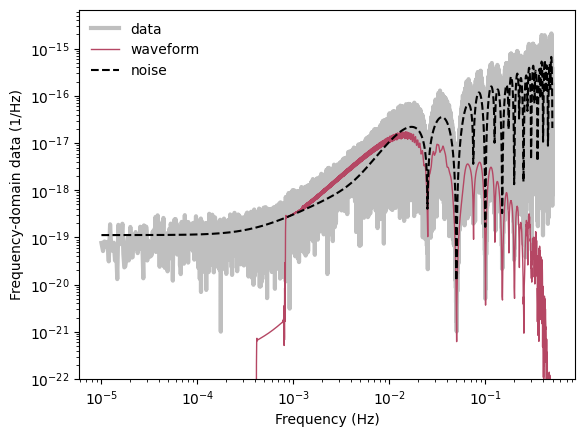

In [7]:
plt.loglog(data_frequencies, np.abs(data_channels[0]), linewidth=3, color="grey", label="data", alpha=0.5)
plt.loglog(data_frequencies, np.abs(wf_channels[0]), linewidth=1, color=RED, label="waveform")
plt.loglog(data_frequencies, np.sqrt(PSD_channels[0] * Tobs / 2.), color="k", linestyle="--", label="noise")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Frequency-domain data (1/Hz)")
plt.legend(loc="upper left", frameon=False)
plt.ylim(1e-22,)

## Fisher analysis 

In [15]:
def fisher_waveform_wrapper(param_dict, frequencies):
    res = FDTDI_HM.Response(
        parameters=param_dict, 
        freqs=np.array(frequencies),  
        **response_kwargs_HM, 
    )
    return res

# set initial steps 
analyze_param_step_dict = {
    'chirp_mass': 10.,
    'mass_ratio': 0.01,
    'spin_1z': 0.1,
    'spin_2z': 0.1,
    'reference_time': 0.0001,
    'reference_phase': 0.1,
    'luminosity_distance': 10.,
    'inclination': 0.1,
    'longitude': 0.1,
    'latitude': 0.1,
    'psi': 0.1
    }
for k, v in analyze_param_step_dict.items():
    analyze_param_step_dict[k] = -v 

FIM = MultiChannelFisher(
    waveform_generator=fisher_waveform_wrapper, 
    param_dict=mbhb_parameters, 
    analyze_param_step_dict=analyze_param_step_dict, 
    frequency=data_frequencies, 
    inverse_covariance=InvCovMat, 
    verbose=0,
)

FIM.auto_test_step()
FIM.calculate_Fisher()
FIM.calculate_errors() 

FIM.param_errors

{'chirp_mass': 0.9912443066301427,
 'mass_ratio': 0.005161860422919556,
 'spin_1z': 0.015565149957992892,
 'spin_2z': 0.07032853552351857,
 'reference_time': 6.903103670738738e-06,
 'reference_phase': 0.25928701127452747,
 'luminosity_distance': 99.90582921912043,
 'inclination': 0.016885041264439786,
 'longitude': 0.0010702229849534307,
 'latitude': 0.0010650302877096933,
 'psi': 0.014417715115321196}

## Likelihood

In [9]:
# initialize heterodyned likelihood 
Like = HMLikelihood(
    response_generator=FDTDI_HM, 
    frequency=data_frequencies, 
    data=data_channels, 
    invserse_covariance_matrix=InvCovMat, 
    response_parameters=response_kwargs_HM_like, 
    Fref_waveform=True, 
    use_gpu=False,
)
Like.prepare_het_log_like(base_parameters=mbhb_parameters, num_het_frequency=128)

# use full likelihood as comparison 
Like_full = Likelihood(
    response_generator=FDTDI_HM, 
    frequency=data_frequencies, 
    data=data_channels, 
    invserse_covariance_matrix=InvCovMat, 
    response_parameters=response_kwargs_HM, 
    Fref_waveform=True, 
    use_gpu=False,
)

In [10]:
import bilby 
class bilby_likelihood_wrapper(bilby.Likelihood):
    def __init__(self, type="heterodyned"):
        """ 
            type can be "heterodyned" or "full"
        """
        super().__init__(
            parameters={
                'chirp_mass': None,
                'mass_ratio': None,
                'spin_1z': None,
                'spin_2z': None,
                'reference_time': None,
                'reference_phase': None,
                'luminosity_distance': None,
                'inclination': None,
                'longitude': None,
                'latitude': None,
                'psi': None
            }
        )
        self.like_type = type 

    def log_likelihood(self):
        if self.like_type == "heterodyned": 
            return Like.het_log_like(parameter_array=ParamDict2ParamArrFref(self.parameters))
        else: 
            return Like.full_log_like(parameter_array=ParamDict2ParamArrFref(self.parameters))

## Prior 

In [11]:
# set prior to be 10 sigma around the truths 
priors = bilby.core.prior.PriorDict()
priors["chirp_mass"] = bilby.prior.Uniform(minimum=mbhb_parameters["chirp_mass"]-10.*FIM.param_errors["chirp_mass"], maximum=mbhb_parameters["chirp_mass"]+10.*FIM.param_errors["chirp_mass"], name='chirp_mass', latex_label='$\mathcal{M}_c$')
priors["mass_ratio"] = bilby.prior.Uniform(minimum=max(0.1, mbhb_parameters["mass_ratio"]-10.*FIM.param_errors["mass_ratio"]), maximum=min(0.99, mbhb_parameters["mass_ratio"]+10.*FIM.param_errors["mass_ratio"]), name="mass_ratio", latex_label='$q$')
priors["spin_1z"] = bilby.prior.Uniform(minimum=max(-0.9, mbhb_parameters["spin_1z"]-10.*FIM.param_errors["spin_1z"]), maximum=min(0.9, mbhb_parameters["spin_1z"]+10.*FIM.param_errors["spin_1z"]), name="spin_1z", latex_label='$\chi_{z1}$')
priors["spin_2z"] = bilby.prior.Uniform(minimum=max(-0.9, mbhb_parameters["spin_2z"]-10.*FIM.param_errors["spin_2z"]), maximum=min(0.9, mbhb_parameters["spin_2z"]+10.*FIM.param_errors["spin_2z"]), name="spin_2z", latex_label='$\chi_{z2}$')
priors["reference_time"] = bilby.prior.Uniform(minimum=mbhb_parameters["reference_time"]-10.*FIM.param_errors["reference_time"], maximum=mbhb_parameters["reference_time"]+10.*FIM.param_errors["reference_time"], name="reference_time", latex_label='$t_\mathrm{ref}$') 
priors["reference_phase"] = bilby.prior.Uniform(minimum=0., maximum=TWOPI, name="reference_phase", latex_label='$\\varphi_\mathrm{ref}$', boundary="periodic")
priors["luminosity_distance"] = bilby.prior.Uniform(minimum=max(LuminosityDistance(1.)/MPC, mbhb_parameters["luminosity_distance"]-10.*FIM.param_errors["luminosity_distance"]), maximum=min(LuminosityDistance(15.)/MPC, mbhb_parameters["luminosity_distance"]+10.*FIM.param_errors["luminosity_distance"]), name="luminosity_distance", latex_label='$d_L$')
priors["inclination"] = bilby.prior.Sine(minimum=0., maximum=PI, name="inclination", latex_label='$\iota$')
priors["longitude"] = bilby.prior.Uniform(minimum=0., maximum=TWOPI, name="longitude", latex_label='$\lambda$', boundary="periodic")
priors["latitude"] = bilby.prior.Cosine(minimum=-PI/2., maximum=PI/2., name="latitude", latex_label='$\\beta$')
priors["psi"] = bilby.prior.Uniform(minimum=0., maximum=PI, name="psi", latex_label='$\psi$', boundary="periodic")

priors

{'chirp_mass': Uniform(minimum=40348.90704689442, maximum=40368.73229434474, name='chirp_mass', latex_label='$\\mathcal{M}_c$', unit=None, boundary=None),
 'mass_ratio': Uniform(minimum=0.24456299435869167, maximum=0.34780267725748726, name='mass_ratio', latex_label='$q$', unit=None, boundary=None),
 'spin_1z': Uniform(minimum=0.44481986941426277, maximum=0.7561282688047598, name='spin_1z', latex_label='$\\chi_{z1}$', unit=None, boundary=None),
 'spin_2z': Uniform(minimum=-0.9, maximum=0.4990620766360242, name='spin_2z', latex_label='$\\chi_{z2}$', unit=None, boundary=None),
 'reference_time': Uniform(minimum=62.37575376157063, maximum=62.3758918277749, name='reference_time', latex_label='$t_\\mathrm{ref}$', unit=None, boundary=None),
 'reference_phase': Uniform(minimum=0.0, maximum=6.283185307179586, name='reference_phase', latex_label='$\\varphi_\\mathrm{ref}$', unit=None, boundary='periodic'),
 'luminosity_distance': Uniform(minimum=6791.7342473851195, maximum=8397.40102402296, name

## Run nested sampling 

In [ ]:
from datetime import datetime
nlive = 800

BLike = bilby_likelihood_wrapper()

ncpu = multiprocessing.cpu_count()
print("number of cpus =", ncpu)

timestamp = datetime.now().strftime("%y%m%d%H")

result = bilby.run_sampler(
    likelihood=BLike, 
    priors=priors,
    sampler="nessai", 
    nlive=nlive, 
    stopping=0.1, 
    npool=ncpu, # use all cpus 
    injection_parameters=mbhb_parameters, 
    outdir="Samples",
    label=f"mbhb_{timestamp}",
    plot=True,
    resume=False, 
    allow_multi_valued_likelihood=True,
)

15:19 bilby INFO    : Running for label 'mbhb_26060815', output will be saved to 'Samples'


number of cpus = 12


/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/bilby/core/utils/log.py:73: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  vdict[key] = str(getattr(sys.modules[key], "__version__", "N/A"))
15:19 bilby INFO    : Analysis priors:
15:19 bilby INFO    : chirp_mass=Uniform(minimum=40348.90704689442, maximum=40368.73229434474, name='chirp_mass', latex_label='$\\mathcal{M}_c$', unit=None, boundary=None)
15:19 bilby INFO    : mass_ratio=Uniform(minimum=0.24456299435869167, maximum=0.34780267725748726, name='mass_ratio', latex_label='$q$', unit=None, boundary=None)
15:19 bilby INFO    : spin_1z=Uniform(minimum=0.44481986941426277, maximum=0.7561282688047598, name='spin_1z', latex_label='$\\chi_{z1}$', unit=None, boundary=None)
15:19 bilby INFO    : spin_2z=Uniform(minimum=-0.9, maximum=0.4990620766360242, name='spin_2z', latex_label='$\\chi_{

06-08 15:19 nessai INFO    : Running Nessai version 0.14.0.post0
06-08 15:19 nessai INFO    : Starting multiprocessing pool with 12 processes


/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/nessai/utils/logging.py:133: FutureWarning: setup_logger is deprecated, use configure_logger instead
  warnings.warn(


06-08 15:19 nessai INFO    : Initialising nested sampler
06-08 15:19 nessai WARNING : Multi-valued likelihood is allowed. This may lead to slow sampling and strange results.
06-08 15:19 nessai WARNING : Multiprocessing pool has already been configured.
06-08 15:19 nessai WARNING : Removing unused keyword arguments ({'enforce_likelihood_threshold', 'step_type', 'n_accept', 'step_kwargs', 'ensemble_fraction', 'n_marg', 'max_n_clusters', 'plot_chain', 'augment_dims', 'n_steps', 'marginalise_augment', 'plot_history', 'generate_augment'}) from kwargs for FlowProposal. These are valid keyword arguments but correspond to other proposal classes.
06-08 15:19 nessai INFO    : Passing kwargs to FlowProposal: {'training_config': None, 'poolsize': 1000, 'check_acceptance': False, 'max_poolsize_scale': 10, 'update_poolsize': True, 'accumulate_weights': False, 'save_training_data': False, 'reparameterisations': None, 'fallback_reparameterisation': 'zscore', 'use_default_reparameterisations': None, 'r

17:39 bilby INFO    : Sampling time: 2:19:47.730779
17:39 bilby INFO    : Summary of results:
nsamples: 2970
ln_noise_evidence:    nan
ln_evidence: 174422.170 +/-  0.305
ln_bayes_factor:    nan +/-  0.305



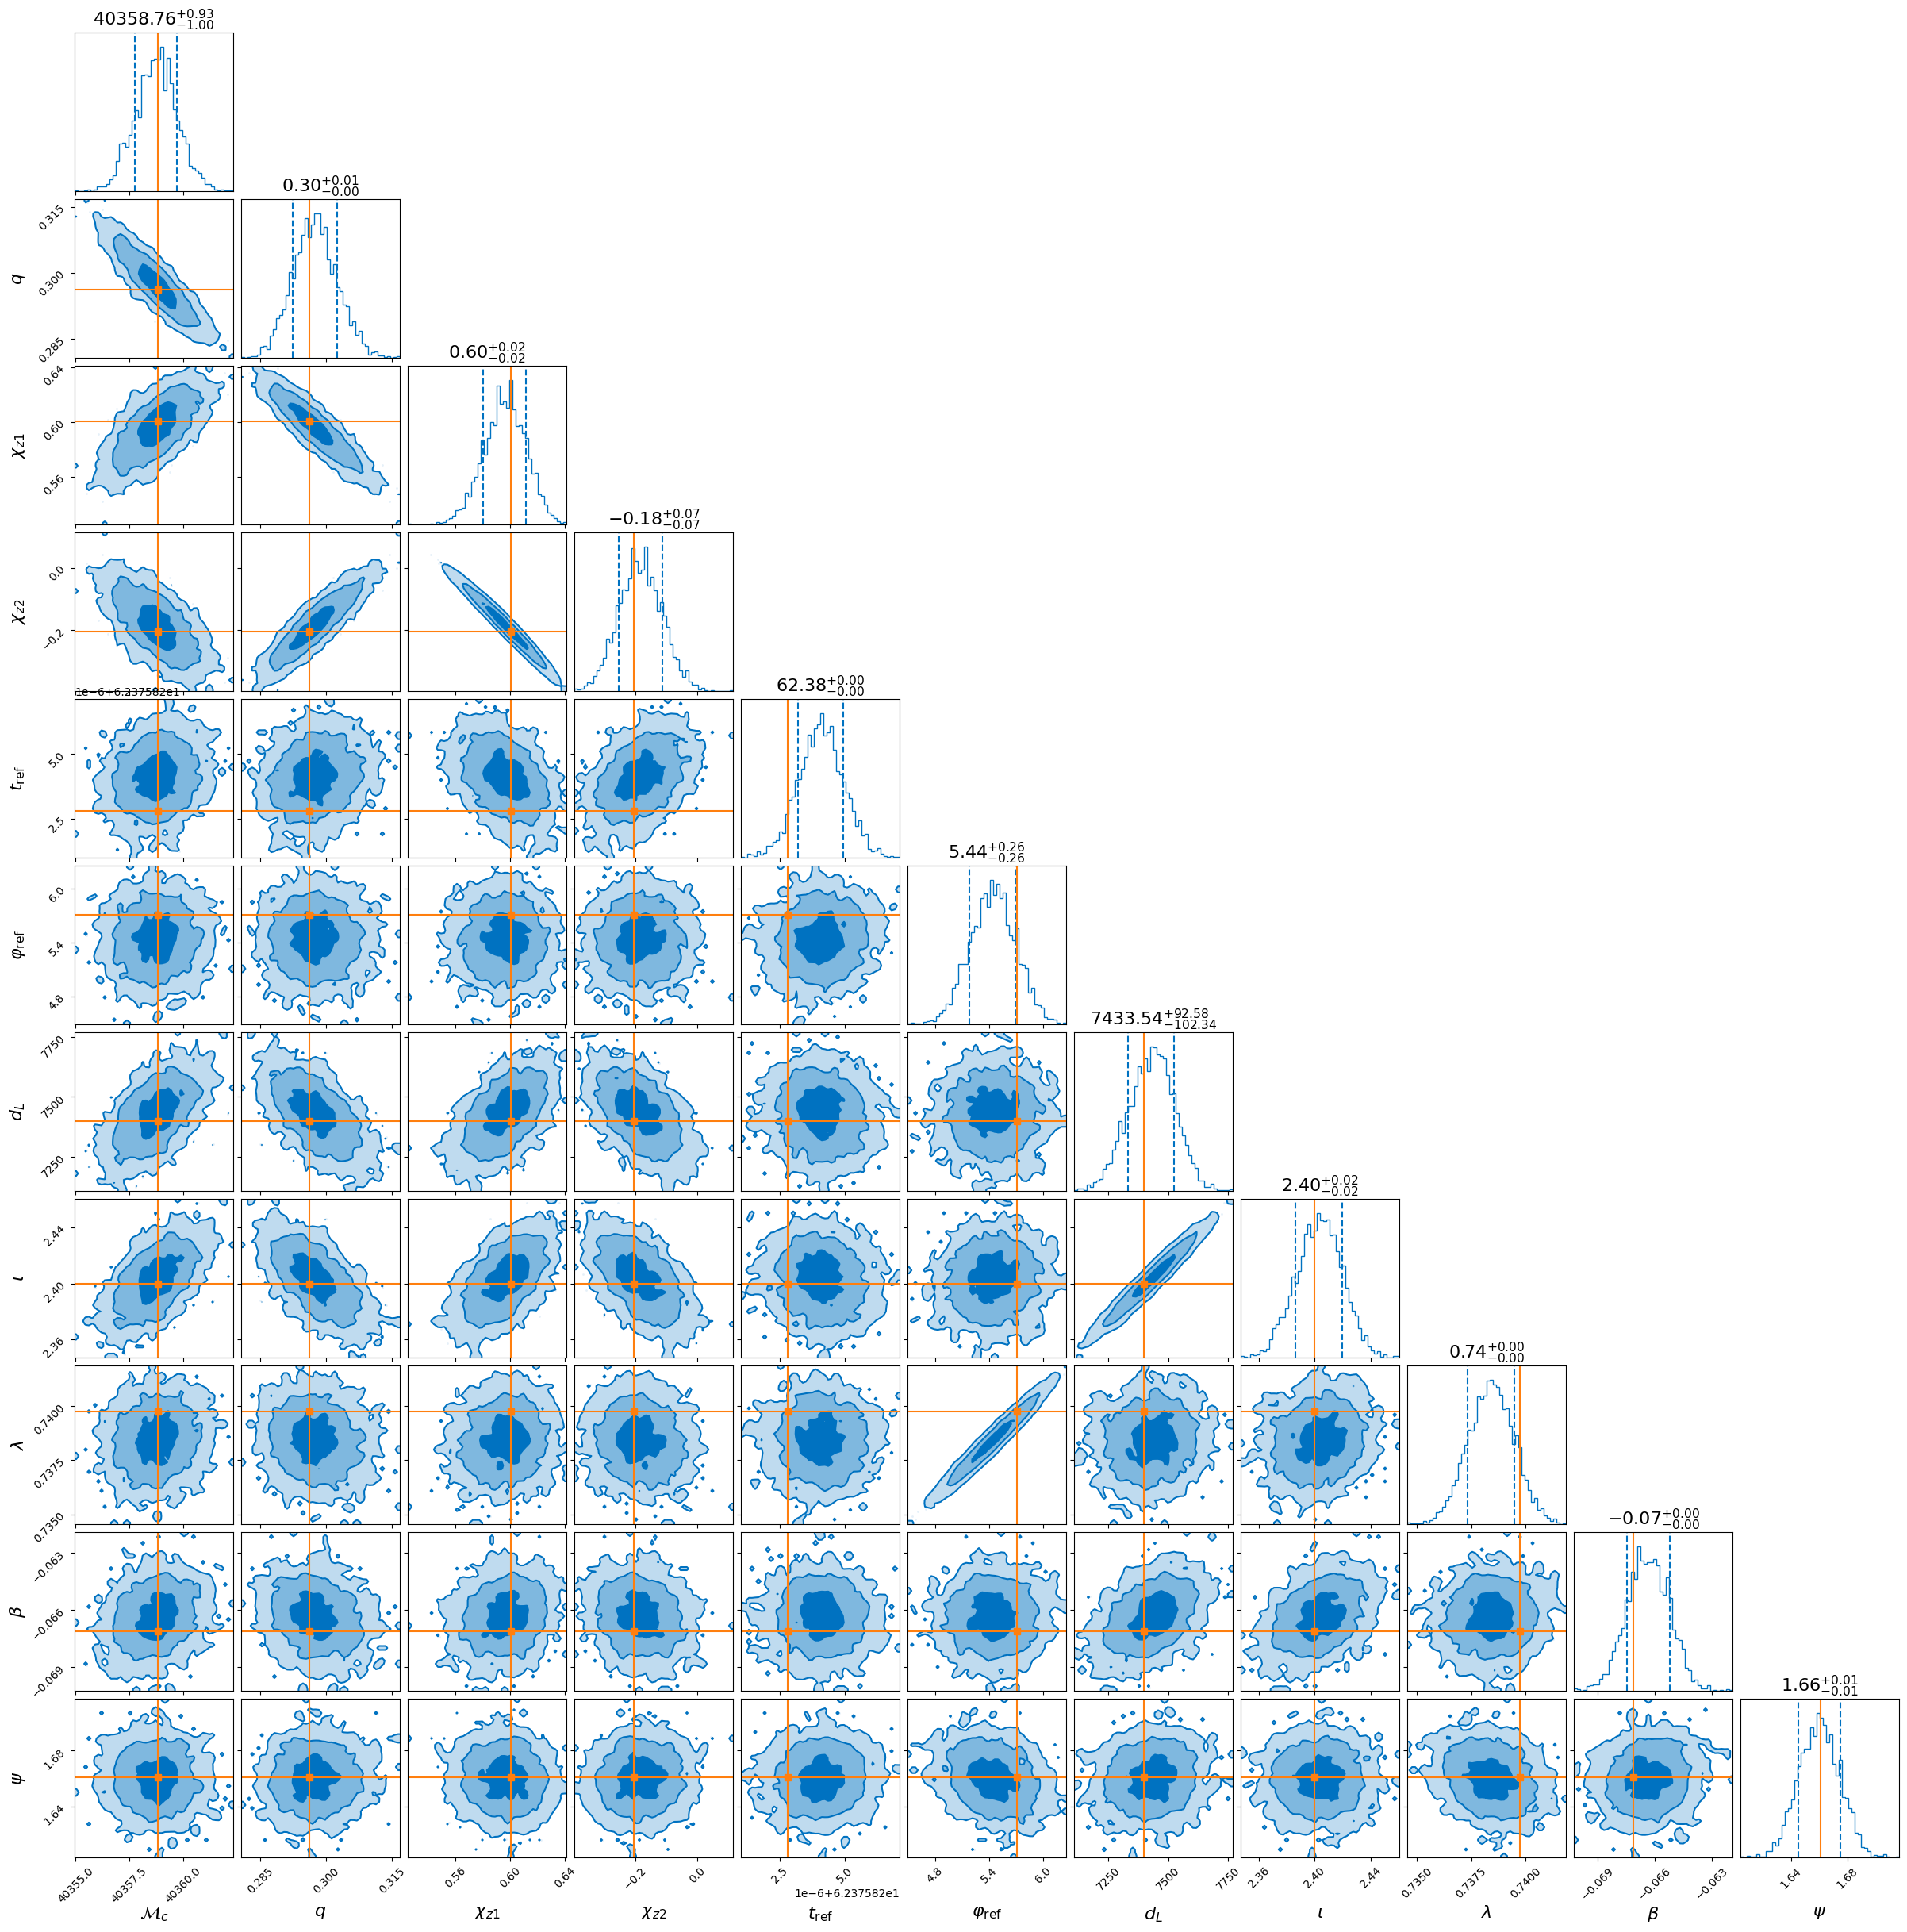

In [13]:
result.plot_corner(save=True)